# Mam's Dataset Segmentation — 3-STAGE PIPELINE + PEAK-ALIGNMENT FIX

## Why your pcorr / cossim results looked wrong

Your `onsets` array almost certainly marks the **start / detection sample** of each IED,
not the sample where the discharge actually **peaks**. The previous version of this
notebook took that marker at face value and just sliced `[onset-32, onset+32)` — i.e. it
*assumed* `onset == peak`. If that assumption is wrong (very common: spike detectors and
manual markings usually flag onset or a fixed-latency trigger, not the true amplitude
maximum), the real spike could sit anywhere in the window instead of exactly at index 32.
That smears out the sharp morphology that should make an IED window look very different
from a non-IED window — which is exactly the symptom you described: IED and non-IED
segments end up looking almost the same to a scEEG↔iEEG mapping model, so their
pcorr/cossim end up close together instead of IED being clearly higher.

**Fix in this version:** before cutting any IED window, we run a small **peak-refinement**
step — for every raw onset we search a short window around it (`PEAK_SEARCH_RADIUS_SAMPLES`,
default ±16 samples ≈ ±62 ms) in the iEEG signal (the modality IEDs are actually detected
on) and pick the sample with the **largest absolute deflection** across iEEG channels as
the *true* peak. The 64-sample window is then centered on that true peak, so index 32 is
guaranteed to be the actual spike maximum, not just wherever the raw marker happened to
land. Two new diagnostic cells (Section 9) let you *see* this directly, before you even
touch the model again:

1. **Grand-average |amplitude| vs. sample index**, IED vs. non-IED — a correctly aligned
   IED set should show a sharp, narrow bump exactly at index 32 that the non-IED curve
   does not have. A flat / smeared bump means peaks are still not well aligned.
2. **Per-segment EEG↔iEEG Pearson-corr and cosine-similarity**, IED vs. non-IED, as
   box-plots — this is the *exact* metric you're seeing in your model, computed directly
   on the segmented data with no model in the loop. If IED isn't clearly higher than
   non-IED here, the problem is upstream of the model (segmentation / the onsets
   themselves), not the model architecture.

You can flip `REFINE_PEAK = False` in the config cell to reproduce the old (unrefined)
behaviour for comparison.

## The three output stages (unchanged from before)

1. **Stage 1 — `segmented_dataset.npz`**: every subject's *entire* recording chopped into
   consecutive, unlabeled 64-sample (250 ms) windows. No onset info used.
2. **Stage 2 — `balanced_segmented_dataset.npz`** (+ `.csv`, `_split.npz`): per subject,
   `n_target` = that subject's own usable IED count. `n_target` IED windows (now
   peak-aligned) + `n_target` non-IED windows (guard zone away from every real peak).
3. **Stage 3 — `leftover_non_ied_segments.npz`**: every valid non-overlapping non-IED
   window found per subject but not needed to balance Stage 2.

Segment length = 64 samples = 250 ms at 256 Hz throughout.

Input file: `20_aug_continuous_eeg_ieeg_dataset12318_SUBJECTS_256hz.npz`

| key | shape | meaning |
|---|---|---|
| `eeg` | (18, 20, 307200) | scalp EEG, (subjects, channels, time) |
| `ieeg` | (18, 12, 307200) | intracranial FO channels, (subjects, channels, time) |
| `onsets` | (18, 500) | IED onset sample-indices per subject, `-1` padded |
| `subject_ids` | (18,) | `sub-01` ... `sub-18` |
| `eeg_names` | (20,) | scalp channel names |
| `fo_names` | (12,) | iEEG channel names |
| `fs` | scalar | 256 Hz |


## 1. Config

In [1]:

import numpy as np
import pandas as pd
import os

# ---- paths ----
DATA_PATH = "20_aug_continuous_eeg_ieeg_dataset12318_SUBJECTS_256hz.npz"   # update if not in same folder
OUT_DIR   = "."                                                            # where outputs are written

# Stage 1 -- full unlabeled segmentation
SEGMENTED_ALL_NPZ = os.path.join(OUT_DIR, "segmented_dataset.npz")

# Stage 2 -- per-subject balanced IED / non-IED dataset (peak-aligned)
NPZ_OUT   = os.path.join(OUT_DIR, "balanced_segmented_dataset.npz")
CSV_OUT   = os.path.join(OUT_DIR, "balanced_segmented_dataset.csv")
SPLIT_OUT = os.path.join(OUT_DIR, "balanced_segmented_dataset_split.npz")

# Stage 3 -- leftover (unused) non-IED segments found while balancing
LEFTOVER_NPZ = os.path.join(OUT_DIR, "leftover_non_ied_segments.npz")

# ---- segmentation config (matches the spec exactly) ----
SEG_LEN   = 64     # 64 samples @ 256 Hz = 250 ms total window
HALF_WIN  = 32     # true peak sits at this index -> 125 ms before + 125 ms after
GUARD_MULT = 2     # non-IED windows (stage 2/3) must stay >= GUARD_MULT*HALF_WIN samples from any real peak
RANDOM_SEED = 42

# ---- Stage 1 only: gap (in samples) left between consecutive full-recording chunks ----
GAP_SAMPLES = 0    # 0 = perfectly back-to-back (1200s / 0.25s = 4800 segments/subject)

# ---- PEAK-ALIGNMENT FIX (Stage 2) ----
# The raw `onsets` marker is often the DETECTION/ONSET sample, not the true amplitude
# peak. Refine each onset by searching a small local window for the sample with the
# largest absolute deflection, and center the 64-sample IED window on THAT sample so
# index 32 really is the spike peak.
REFINE_PEAK              = True     # set False to reproduce the old "trust the raw onset" behaviour
PEAK_SEARCH_RADIUS_SAMPLES = 16     # +/- samples (~62 ms at 256 Hz) searched around each raw onset
PEAK_CHANNELS             = "ieeg"  # "ieeg" (recommended: IEDs are detected here), "eeg", or "both"

# ---- train/val/test split (subject-wise, so no subject leaks across splits) ----
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9

rng = np.random.default_rng(RANDOM_SEED)


## 2. Load the continuous dataset

In [2]:

data = np.load(DATA_PATH, allow_pickle=True)

eeg          = data["eeg"]          # (18, 20, 307200)
ieeg         = data["ieeg"]         # (18, 12, 307200)
onsets_all   = data["onsets"]       # (18, 500), -1 padded
subject_ids  = data["subject_ids"]  # (18,)
eeg_names    = list(data["eeg_names"])
fo_names     = list(data["fo_names"])
fs           = float(data["fs"])

n_subjects, n_eeg_ch, n_samples = eeg.shape
n_ieeg_ch = ieeg.shape[1]

print(f"Subjects        : {n_subjects}")
print(f"EEG channels    : {n_eeg_ch} -> {eeg_names}")
print(f"iEEG channels   : {n_ieeg_ch} -> {fo_names}")
print(f"Samples/subject : {n_samples}  (fs={fs} Hz, {n_samples/fs:.1f} s = {n_samples/fs/60:.1f} min)")
print(f"Segment length  : {SEG_LEN} samples = {SEG_LEN/fs*1000:.0f} ms  (true peak forced at index {HALF_WIN})")


Subjects        : 18
EEG channels    : 20 -> [np.str_('Fp1'), np.str_('Fp2'), np.str_('F7'), np.str_('F3'), np.str_('Fz'), np.str_('F4'), np.str_('F8'), np.str_('T3'), np.str_('C3'), np.str_('Cz'), np.str_('C4'), np.str_('T4'), np.str_('T5'), np.str_('P3'), np.str_('Pz'), np.str_('P4'), np.str_('T6'), np.str_('O1'), np.str_('O2'), np.str_('Oz')]
iEEG channels   : 12 -> [np.str_('LFO1'), np.str_('LFO2'), np.str_('LFO3'), np.str_('LFO4'), np.str_('LFO5'), np.str_('LFO6'), np.str_('RFO1'), np.str_('RFO2'), np.str_('RFO3'), np.str_('RFO4'), np.str_('RFO5'), np.str_('RFO6')]
Samples/subject : 307200  (fs=256.0 Hz, 1200.0 s = 20.0 min)
Segment length  : 64 samples = 250 ms  (true peak forced at index 32)


## 3. STAGE 1 — Full unlabeled segmentation (every subject, whole recording)

Just chop each subject's continuous signal into consecutive `SEG_LEN`-sample windows,
**no onset info used, no labels, no balancing**
(`1200 s / 0.25 s = 4800` windows/subject when `GAP_SAMPLES = 0`).

In [3]:

def chop_continuous_segments(eeg_subj, ieeg_subj, seg_len, gap):
    """
    eeg_subj  : (n_eeg_ch, n_samples)
    ieeg_subj : (n_ieeg_ch, n_samples)

    Returns X_eeg (n_win, seg_len, n_eeg_ch), X_ieeg (n_win, seg_len, n_ieeg_ch), starts (n_win,)
    """
    step = seg_len + gap
    n_samp = eeg_subj.shape[1]
    starts = np.arange(0, n_samp - seg_len + 1, step, dtype=np.int64)

    eeg_t  = eeg_subj.T   # (n_samples, n_eeg_ch)
    ieeg_t = ieeg_subj.T  # (n_samples, n_ieeg_ch)

    X_eeg  = np.stack([eeg_t[s:s + seg_len]  for s in starts], axis=0)
    X_ieeg = np.stack([ieeg_t[s:s + seg_len] for s in starts], axis=0)
    return X_eeg, X_ieeg, starts


Xa_eeg_list, Xa_ieeg_list, starts_list, subj_a_list = [], [], [], []

for i in range(n_subjects):
    Xa_eeg_i, Xa_ieeg_i, starts_i = chop_continuous_segments(eeg[i], ieeg[i], SEG_LEN, GAP_SAMPLES)
    Xa_eeg_list.append(Xa_eeg_i)
    Xa_ieeg_list.append(Xa_ieeg_i)
    starts_list.append(starts_i)
    subj_a_list.append(np.full(len(starts_i), subject_ids[i]))
    print(f"{subject_ids[i]}: {len(starts_i)} unlabeled 64-sample segments")

X_eeg_all  = np.concatenate(Xa_eeg_list, axis=0).astype(np.float32)   # (N_all, 64, 20)
X_ieeg_all = np.concatenate(Xa_ieeg_list, axis=0).astype(np.float32)  # (N_all, 64, 12)
seg_start_all    = np.concatenate(starts_list, axis=0)                # (N_all,) window start sample
seg_subject_all  = np.concatenate(subj_a_list, axis=0)                # (N_all,)

print(f"\nTotal unlabeled segments across all subjects: {len(seg_start_all)}")
print(f"X_eeg_all  shape: {X_eeg_all.shape}")
print(f"X_ieeg_all shape: {X_ieeg_all.shape}")


sub-01: 4800 unlabeled 64-sample segments
sub-02: 4800 unlabeled 64-sample segments
sub-03: 4800 unlabeled 64-sample segments
sub-04: 4800 unlabeled 64-sample segments
sub-05: 4800 unlabeled 64-sample segments
sub-06: 4800 unlabeled 64-sample segments
sub-07: 4800 unlabeled 64-sample segments
sub-08: 4800 unlabeled 64-sample segments
sub-09: 4800 unlabeled 64-sample segments
sub-10: 4800 unlabeled 64-sample segments
sub-11: 4800 unlabeled 64-sample segments
sub-12: 4800 unlabeled 64-sample segments
sub-13: 4800 unlabeled 64-sample segments
sub-14: 4800 unlabeled 64-sample segments
sub-15: 4800 unlabeled 64-sample segments
sub-16: 4800 unlabeled 64-sample segments
sub-17: 4800 unlabeled 64-sample segments
sub-18: 4800 unlabeled 64-sample segments

Total unlabeled segments across all subjects: 86400
X_eeg_all  shape: (86400, 64, 20)
X_ieeg_all shape: (86400, 64, 12)


### 3.1 Save Stage 1 output -> `segmented_dataset.npz` (unlabeled)

In [4]:

np.savez(
    SEGMENTED_ALL_NPZ,
    X_eeg=X_eeg_all,                       # (N_all, 64, 20) float32 -- NOT labeled, NOT balanced
    X_ieeg=X_ieeg_all,                     # (N_all, 64, 12) float32
    start_idx=seg_start_all,               # (N_all,) sample index each window starts at, within its subject
    subject_ids=seg_subject_all,           # (N_all,) which subject each segment came from
    eeg_names=np.array(eeg_names),
    fo_names=np.array(fo_names),
    fs=fs,
    seg_len=SEG_LEN,
    gap_samples=GAP_SAMPLES,
)
print("Saved:", SEGMENTED_ALL_NPZ)
print("File size (MB):", os.path.getsize(SEGMENTED_ALL_NPZ) / 1e6)


Saved: .\segmented_dataset.npz
File size (MB): 710.556302


## 4. Usable onsets per subject (raw markers, before peak refinement)

An onset is *usable* if it is not padding (`!= -1`) and its full `[onset-32, onset+32)`
window fits inside the recording. This is still computed from the **raw** markers so we
can compare "raw" vs "refined" counts in the next section.

In [5]:

usable_onsets_per_subject = []
rows = []
for i in range(n_subjects):
    valid = onsets_all[i][onsets_all[i] != -1]
    valid = valid[(valid - HALF_WIN >= 0) & (valid + HALF_WIN <= n_samples)]
    valid = np.unique(valid)                      # guard against accidental duplicate onsets
    usable_onsets_per_subject.append(valid)
    rows.append({"Subject": subject_ids[i], "Raw usable onsets": len(valid)})

usable_table = pd.DataFrame(rows)
display(usable_table)
print("\nTotal raw usable onsets:", usable_table["Raw usable onsets"].sum())


,Subject,Raw usable onsets
0,sub-01,256
1,sub-02,447
2,sub-03,446
3,sub-04,360
4,sub-05,500
5,sub-06,402
6,sub-07,481
7,sub-08,327
8,sub-09,500
9,sub-10,192



Total raw usable onsets: 6388


## 5. PEAK REFINEMENT — find the true spike peak near each raw onset

For every raw onset `t`, look at a small local window `[t - PEAK_SEARCH_RADIUS_SAMPLES,
t + PEAK_SEARCH_RADIUS_SAMPLES]` in the `PEAK_CHANNELS` signal (iEEG by default — that's
the modality these IEDs are actually detected on) and pick the sample with the **largest
absolute deflection across channels**. That sample becomes the new "onset" used for
extraction, so the 64-sample window built around it truly has the spike peak at index 32.

A few onsets may end up merging (two close raw markers refining to the same peak) or
falling out of bounds (peak too close to the edge of the recording) — both are reported
below, and the shift histogram shows how far the raw markers were from the true peaks
(a spread of ±0 would mean the raw markers were already exact; anything wider than a
couple of samples is exactly the kind of misalignment that would blur IED vs non-IED
apart in your model).

,Subject,Raw usable onsets,Refined peaks (final),Dropped (out of bounds),Merged duplicates,Mean |shift| (samples),Max |shift| (samples)
0,sub-01,256,256,0,0,8.703125,16
1,sub-02,447,447,0,0,9.154362,16
2,sub-03,446,446,0,0,9.645740,16
3,sub-04,360,360,0,0,10.119444,16
4,sub-05,500,500,0,0,9.552000,16
5,sub-06,402,402,0,0,9.251244,16
6,sub-07,481,481,0,0,10.045738,16
7,sub-08,327,327,0,0,10.235474,16
8,sub-09,500,500,0,0,9.388000,16
9,sub-10,192,192,0,0,9.848958,16



Total refined peaks (== total IED segments == total non-IED segments used for balancing): 6388


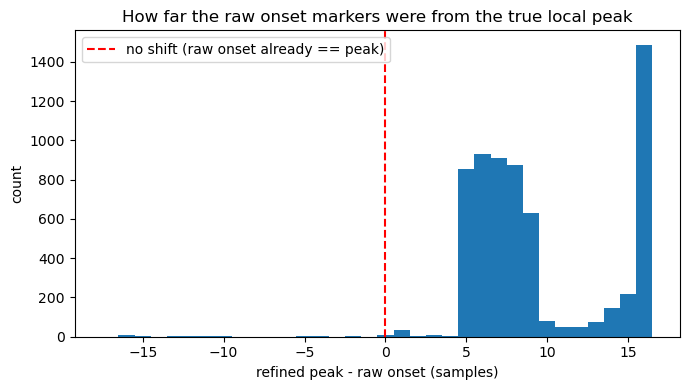

Mean |shift| across all subjects: 9.59 samples (37.5 ms)


In [6]:

def find_local_peak(onset, sig_t, search_radius, n_samples):
    """sig_t: (n_samples, n_channels). Returns the global sample index of max |deflection|
    across channels, within +/- search_radius of `onset`."""
    lo = max(0, onset - search_radius)
    hi = min(n_samples, onset + search_radius + 1)
    window = sig_t[lo:hi]                      # (w, n_channels)
    mag = np.max(np.abs(window), axis=1)       # strongest channel's |amplitude| at each sample
    return lo + int(np.argmax(mag))


def refine_onsets_to_peak(onsets_subj, peak_sig_t, n_samples, search_radius, half_win):
    """
    Refine every raw onset to the true local peak sample in `peak_sig_t`.
    Returns (peaks_unique_sorted, all_shifts_before_dedup, n_out_of_bounds, n_merged_duplicates).
    """
    raw = np.asarray(onsets_subj)
    if len(raw) == 0:
        return raw.copy(), np.array([], dtype=np.int64), 0, 0

    peaks = np.array([find_local_peak(t, peak_sig_t, search_radius, n_samples) for t in raw])
    shifts = peaks - raw

    in_bounds = (peaks - half_win >= 0) & (peaks + half_win <= n_samples)
    n_oob = int((~in_bounds).sum())
    peaks_ib, shifts_ib = peaks[in_bounds], shifts[in_bounds]

    peaks_unique = np.unique(peaks_ib)
    n_dupes = len(peaks_ib) - len(peaks_unique)

    return peaks_unique, shifts_ib, n_oob, n_dupes


def get_peak_signal(eeg_subj, ieeg_subj, mode):
    if mode == "ieeg":
        return ieeg_subj.T
    elif mode == "eeg":
        return eeg_subj.T
    elif mode == "both":
        return np.concatenate([eeg_subj.T, ieeg_subj.T], axis=1)
    else:
        raise ValueError(f"Unknown PEAK_CHANNELS={mode!r}, expected 'ieeg', 'eeg', or 'both'")


refined_onsets_per_subject = []
shift_rows = []
all_shifts = []

for i in range(n_subjects):
    if REFINE_PEAK:
        peak_sig_t = get_peak_signal(eeg[i], ieeg[i], PEAK_CHANNELS)
        peaks, shifts, n_oob, n_dupes = refine_onsets_to_peak(
            usable_onsets_per_subject[i], peak_sig_t, n_samples, PEAK_SEARCH_RADIUS_SAMPLES, HALF_WIN
        )
    else:
        peaks = usable_onsets_per_subject[i]
        shifts = np.zeros(len(peaks), dtype=np.int64)
        n_oob, n_dupes = 0, 0

    refined_onsets_per_subject.append(peaks)
    all_shifts.extend(shifts.tolist())
    shift_rows.append({
        "Subject": subject_ids[i],
        "Raw usable onsets": len(usable_onsets_per_subject[i]),
        "Refined peaks (final)": len(peaks),
        "Dropped (out of bounds)": n_oob,
        "Merged duplicates": n_dupes,
        "Mean |shift| (samples)": float(np.mean(np.abs(shifts))) if len(shifts) else 0.0,
        "Max |shift| (samples)": int(np.max(np.abs(shifts))) if len(shifts) else 0,
    })

shift_table = pd.DataFrame(shift_rows)
display(shift_table)
print(f"\nTotal refined peaks (== total IED segments == total non-IED segments used for balancing): "
      f"{shift_table['Refined peaks (final)'].sum()}")

if REFINE_PEAK and len(all_shifts) > 0:
    import matplotlib.pyplot as plt
    all_shifts_arr = np.array(all_shifts)
    plt.figure(figsize=(7, 4))
    plt.hist(all_shifts_arr, bins=np.arange(all_shifts_arr.min() - 1, all_shifts_arr.max() + 2) - 0.5)
    plt.axvline(0, color="r", linestyle="--", label="no shift (raw onset already == peak)")
    plt.xlabel("refined peak - raw onset (samples)")
    plt.ylabel("count")
    plt.title("How far the raw onset markers were from the true local peak")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"Mean |shift| across all subjects: {np.mean(np.abs(all_shifts_arr)):.2f} samples "
          f"({np.mean(np.abs(all_shifts_arr))/fs*1000:.1f} ms)")


## 6. Fast non-overlapping non-IED window sampler

Same vectorized approach as before. `sample_all_non_overlapping_starts` does **not**
stop once it has `n_target` windows — it returns **every** valid non-overlapping window
it can find. Stage 2 keeps the first `n_target` for balancing; Stage 3 saves the rest.
The exclude zone is now built from the **refined peaks**, so non-IED windows correctly
avoid the true spike locations rather than the (possibly offset) raw markers.

In [7]:

def build_exclude_mask(all_onsets, n_samples, half_win, guard_mult):
    guard = guard_mult * half_win
    mask = np.zeros(n_samples, dtype=bool)
    for t in all_onsets:
        s = max(0, t - guard)
        e = min(n_samples, t + guard)
        mask[s:e] = True
    return mask


def valid_window_starts(exclude_mask, seg_len):
    """All start indices s such that exclude_mask[s:s+seg_len] is entirely False."""
    n_samples = len(exclude_mask)
    max_start = n_samples - seg_len
    csum = np.concatenate(([0], np.cumsum(exclude_mask)))
    window_sum = csum[seg_len:seg_len + max_start + 1] - csum[:max_start + 1]
    return np.where(window_sum == 0)[0]


def sample_all_non_overlapping_starts(valid_starts, seg_len, n_samples, rng):
    """Greedily pick ALL mutually non-overlapping starts out of valid_starts (random order)."""
    avail = np.zeros(n_samples, dtype=bool)
    avail[valid_starts] = True
    order = rng.permutation(valid_starts)
    chosen = []
    for s in order:
        if not avail[s]:
            continue
        chosen.append(int(s))
        lo = max(0, s - seg_len + 1)
        hi = min(n_samples, s + seg_len)
        avail[lo:hi] = False
    return chosen


## 7. STAGE 2 & 3 — Per-subject extraction: balanced set + leftover non-IED

`onsets_subj` passed in here is now the **refined peak** array from Section 5, so
`eeg_t[t - half_win : t + half_win]` really is centered on the true spike maximum.

In [8]:

def extract_subject_segments(eeg_subj, ieeg_subj, onsets_subj, n_samples,
                              seg_len=SEG_LEN, half_win=HALF_WIN, guard_mult=GUARD_MULT, rng=rng):
    """
    eeg_subj    : (n_eeg_ch, n_samples)
    ieeg_subj   : (n_ieeg_ch, n_samples)
    onsets_subj : this subject's REFINED peak samples (1D array)

    Returns
    -------
    X_eeg, X_ieeg : (2*n_target, seg_len, n_ch)   balanced IED + non-IED segments
    y             : (2*n_target,)  1 = IED, 0 = non-IED
    n_target      : number of IED (== number of non-IED used) segments for this subject
    leftover_eeg, leftover_ieeg : (n_leftover, seg_len, n_ch)  UNUSED non-IED segments
    leftover_starts : (n_leftover,) sample index each leftover window starts at
    """
    eeg_t  = eeg_subj.T    # (n_samples, n_eeg_ch)
    ieeg_t = ieeg_subj.T   # (n_samples, n_ieeg_ch)

    n_target = len(onsets_subj)

    # ---- IED segments: true peak forced at index `half_win`, one per refined onset ----
    ied_eeg  = np.stack([eeg_t[t - half_win: t + half_win]  for t in onsets_subj], axis=0)
    ied_ieeg = np.stack([ieeg_t[t - half_win: t + half_win] for t in onsets_subj], axis=0)

    # ---- non-IED candidates: ALL non-overlapping windows away from every real peak ----
    exclude_mask = build_exclude_mask(onsets_subj, n_samples, half_win, guard_mult)
    starts = valid_window_starts(exclude_mask, seg_len)
    all_non_starts = sample_all_non_overlapping_starts(starts, seg_len, n_samples, rng)

    if len(all_non_starts) < n_target:
        raise RuntimeError(
            f"Only found {len(all_non_starts)}/{n_target} non-overlapping non-IED windows. "
            f"Lower GUARD_MULT (currently {guard_mult}) and re-run."
        )

    chosen_starts   = all_non_starts[:n_target]   # used for balancing
    leftover_starts = all_non_starts[n_target:]   # unused -> Stage 3

    non_eeg  = np.stack([eeg_t[s:s + seg_len]  for s in chosen_starts], axis=0)
    non_ieeg = np.stack([ieeg_t[s:s + seg_len] for s in chosen_starts], axis=0)

    X_eeg  = np.concatenate([ied_eeg, non_eeg], axis=0)
    X_ieeg = np.concatenate([ied_ieeg, non_ieeg], axis=0)
    y = np.concatenate([np.ones(n_target, dtype=np.int64), np.zeros(n_target, dtype=np.int64)])

    if len(leftover_starts) > 0:
        leftover_eeg  = np.stack([eeg_t[s:s + seg_len]  for s in leftover_starts], axis=0)
        leftover_ieeg = np.stack([ieeg_t[s:s + seg_len] for s in leftover_starts], axis=0)
    else:
        leftover_eeg  = np.zeros((0, seg_len, eeg_t.shape[1]), dtype=eeg_t.dtype)
        leftover_ieeg = np.zeros((0, seg_len, ieeg_t.shape[1]), dtype=ieeg_t.dtype)

    return (X_eeg, X_ieeg, y, n_target,
            leftover_eeg, leftover_ieeg, np.array(leftover_starts, dtype=np.int64))


## 8. Run for all subjects and combine (balanced set + leftover non-IED set)

In [9]:

X_eeg_list, X_ieeg_list, y_list, subj_list = [], [], [], []
left_eeg_list, left_ieeg_list, left_start_list, left_subj_list = [], [], [], []

for i in range(n_subjects):
    (X_eeg_i, X_ieeg_i, y_i, n_target_i,
     left_eeg_i, left_ieeg_i, left_starts_i) = extract_subject_segments(
        eeg[i], ieeg[i], refined_onsets_per_subject[i], n_samples
    )
    X_eeg_list.append(X_eeg_i)
    X_ieeg_list.append(X_ieeg_i)
    y_list.append(y_i)
    subj_list.append(np.full(len(y_i), subject_ids[i]))

    left_eeg_list.append(left_eeg_i)
    left_ieeg_list.append(left_ieeg_i)
    left_start_list.append(left_starts_i)
    left_subj_list.append(np.full(len(left_starts_i), subject_ids[i]))

    print(f"{subject_ids[i]}: {n_target_i} IED + {n_target_i} non-IED = {2*n_target_i} balanced segments "
          f"| {len(left_starts_i)} leftover non-IED segments")

# ---- balanced (Stage 2) ----
X_eeg  = np.concatenate(X_eeg_list, axis=0)    # (N, 64, 20)
X_ieeg = np.concatenate(X_ieeg_list, axis=0)   # (N, 64, 12)
y      = np.concatenate(y_list, axis=0)        # (N,)
seg_subject_ids = np.concatenate(subj_list, axis=0)   # (N,)

print(f"\nTotal balanced segments : {len(y)}  (IED={int(y.sum())}, non-IED={int((y==0).sum())})")
print(f"X_eeg  shape   : {X_eeg.shape}")
print(f"X_ieeg shape   : {X_ieeg.shape}")

# ---- per-subject balance check: IED count must equal non-IED count, within each subject ----
check = pd.DataFrame({"subject_id": seg_subject_ids, "label": y})
balance = check.groupby("subject_id")["label"].agg(ied="sum", total="count")
balance["non_ied"] = balance["total"] - balance["ied"]
balance["balanced_ok"] = balance["ied"] == balance["non_ied"]
display(balance)
assert balance["balanced_ok"].all(), "Some subject is NOT balanced (IED != non-IED) -- investigate!"
print("\nAll subjects balanced (IED == non-IED within each subject). Counts differ across subjects, as intended.")

# NOTE: X_eeg, X_ieeg, y, seg_subject_ids are all index-aligned so far (grouped by subject,
# IED block then non-IED block). We shuffle in the NEXT cell, keeping that alignment intact --
# this is what makes X_eeg[k] <-> X_ieeg[k] a valid (input, target) pair for mapping models.
perm = rng.permutation(len(y))
X_eeg, X_ieeg, y, seg_subject_ids = X_eeg[perm], X_ieeg[perm], y[perm], seg_subject_ids[perm]
print("\nShuffled (X_eeg, X_ieeg, y, seg_subject_ids together -- pairing preserved).")

# ---- leftover non-IED (Stage 3) ----
X_eeg_leftover  = np.concatenate(left_eeg_list, axis=0)   if len(left_eeg_list)  else np.zeros((0, SEG_LEN, n_eeg_ch))
X_ieeg_leftover = np.concatenate(left_ieeg_list, axis=0)  if len(left_ieeg_list) else np.zeros((0, SEG_LEN, n_ieeg_ch))
leftover_starts_all   = np.concatenate(left_start_list, axis=0) if len(left_start_list) else np.zeros((0,), dtype=np.int64)
leftover_subject_ids  = np.concatenate(left_subj_list, axis=0)  if len(left_subj_list)  else np.zeros((0,), dtype=subject_ids.dtype)

print(f"\nTotal leftover non-IED segments (unused during balancing): {len(leftover_starts_all)}")
leftover_table = pd.DataFrame({"subject_id": leftover_subject_ids}).value_counts("subject_id").rename("leftover_non_ied").sort_index()
display(leftover_table.to_frame())


sub-01: 256 IED + 256 non-IED = 512 balanced segments | 3043 leftover non-IED segments
sub-02: 447 IED + 447 non-IED = 894 balanced segments | 2580 leftover non-IED segments
sub-03: 446 IED + 446 non-IED = 892 balanced segments | 2758 leftover non-IED segments
sub-04: 360 IED + 360 non-IED = 720 balanced segments | 2920 leftover non-IED segments
sub-05: 500 IED + 500 non-IED = 1000 balanced segments | 2636 leftover non-IED segments
sub-06: 402 IED + 402 non-IED = 804 balanced segments | 2842 leftover non-IED segments
sub-07: 481 IED + 481 non-IED = 962 balanced segments | 2682 leftover non-IED segments
sub-08: 327 IED + 327 non-IED = 654 balanced segments | 2976 leftover non-IED segments
sub-09: 500 IED + 500 non-IED = 1000 balanced segments | 2649 leftover non-IED segments
sub-10: 192 IED + 192 non-IED = 384 balanced segments | 3263 leftover non-IED segments
sub-11: 226 IED + 226 non-IED = 452 balanced segments | 3087 leftover non-IED segments
sub-12: 352 IED + 352 non-IED = 704 balan

,ied,total,non_ied,balanced_ok
subject_id,,,,
sub-01,256,512,256,True
sub-02,447,894,447,True
sub-03,446,892,446,True
sub-04,360,720,360,True
sub-05,500,1000,500,True
sub-06,402,804,402,True
sub-07,481,962,481,True
sub-08,327,654,327,True
sub-09,500,1000,500,True



All subjects balanced (IED == non-IED within each subject). Counts differ across subjects, as intended.

Shuffled (X_eeg, X_ieeg, y, seg_subject_ids together -- pairing preserved).

Total leftover non-IED segments (unused during balancing): 51973


,leftover_non_ied
subject_id,
sub-01,3043
sub-02,2580
sub-03,2758
sub-04,2920
sub-05,2636
sub-06,2842
sub-07,2682
sub-08,2976
sub-09,2649


## 9. Diagnostics — verify peak alignment & IED vs non-IED separability

Three checks, in increasing order of usefulness for your question:

**9.1** — single example, same as before: IED onset should visually sit at the red line
(index 32).

**9.2** — grand-average `|amplitude|` across *all* IED segments vs *all* non-IED segments.
If peaks are well aligned, the IED curve should show a clear, narrow bump right at index
32 that the non-IED curve doesn't have — especially in the iEEG panel, since that's the
modality the peaks were refined on. A flat / smeared IED curve close to the non-IED curve
means many segments still aren't peak-aligned (try increasing `PEAK_SEARCH_RADIUS_SAMPLES`
a bit, or check `PEAK_CHANNELS`).

**9.3** — the actual metric you're computing on the model: per-segment Pearson correlation
and cosine similarity between the (channel-averaged) EEG and iEEG traces, IED vs non-IED,
as box-plots. This is computed directly on the segmented data, with **no model involved**
— if IED isn't clearly higher than non-IED here, the issue is upstream (segmentation /
onset markers), confirming it's not your model architecture.

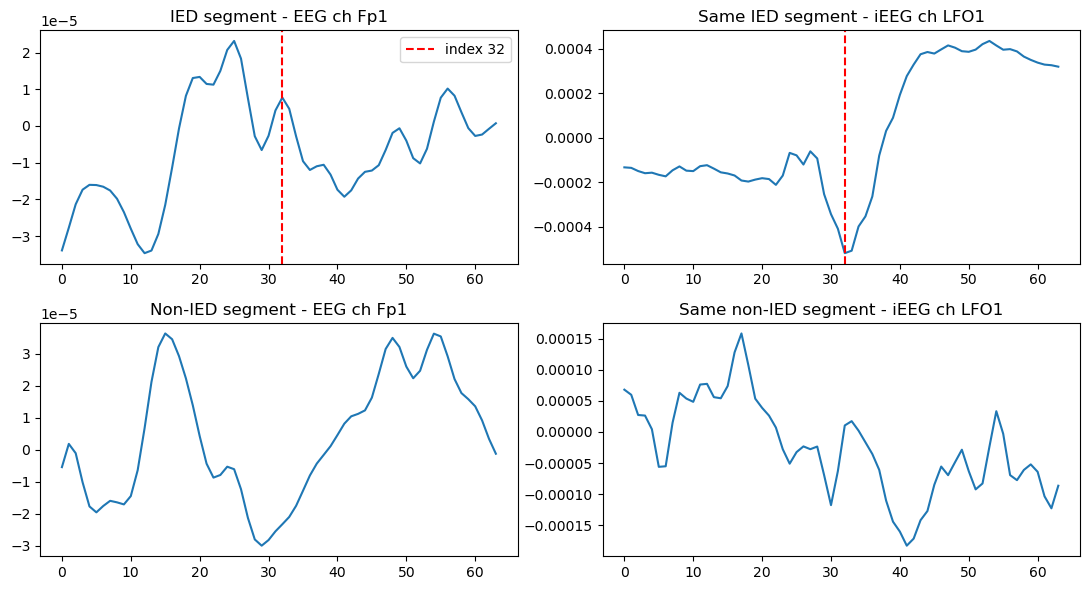

In [10]:

import matplotlib.pyplot as plt

# ---- 9.1 single example ----
ied_idx = np.where(y == 1)[0][0]
non_idx = np.where(y == 0)[0][0]

fig, axes = plt.subplots(2, 2, figsize=(11, 6))

axes[0, 0].plot(X_eeg[ied_idx, :, 0])
axes[0, 0].axvline(HALF_WIN, color="r", linestyle="--", label=f"index {HALF_WIN}")
axes[0, 0].set_title(f"IED segment - EEG ch {eeg_names[0]}")
axes[0, 0].legend()

axes[0, 1].plot(X_ieeg[ied_idx, :, 0])
axes[0, 1].axvline(HALF_WIN, color="r", linestyle="--")
axes[0, 1].set_title(f"Same IED segment - iEEG ch {fo_names[0]}")

axes[1, 0].plot(X_eeg[non_idx, :, 0])
axes[1, 0].set_title(f"Non-IED segment - EEG ch {eeg_names[0]}")

axes[1, 1].plot(X_ieeg[non_idx, :, 0])
axes[1, 1].set_title(f"Same non-IED segment - iEEG ch {fo_names[0]}")

plt.tight_layout()
plt.show()


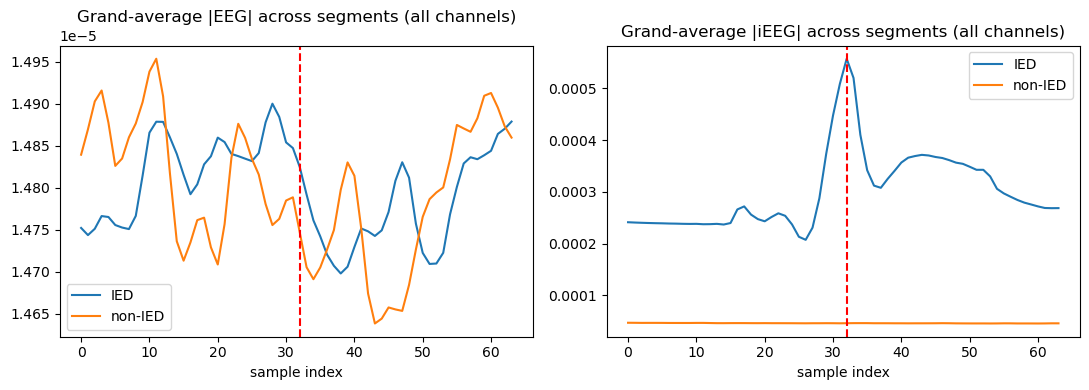

Expect: a sharp, narrow IED bump right at index 32 (especially in the iEEG panel) that
the non-IED curve does not show. A flat/smeared IED curve close to non-IED means many
segments still aren't peak-aligned.


In [11]:

# ---- 9.2 grand-average |amplitude| across all segments ----
mean_abs_ied_eeg  = np.mean(np.abs(X_eeg[y == 1]),  axis=(0, 2))   # (64,)
mean_abs_non_eeg  = np.mean(np.abs(X_eeg[y == 0]),  axis=(0, 2))
mean_abs_ied_ieeg = np.mean(np.abs(X_ieeg[y == 1]), axis=(0, 2))
mean_abs_non_ieeg = np.mean(np.abs(X_ieeg[y == 0]), axis=(0, 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(mean_abs_ied_eeg, label="IED")
axes[0].plot(mean_abs_non_eeg, label="non-IED")
axes[0].axvline(HALF_WIN, color="r", linestyle="--")
axes[0].set_title("Grand-average |EEG| across segments (all channels)")
axes[0].set_xlabel("sample index")
axes[0].legend()

axes[1].plot(mean_abs_ied_ieeg, label="IED")
axes[1].plot(mean_abs_non_ieeg, label="non-IED")
axes[1].axvline(HALF_WIN, color="r", linestyle="--")
axes[1].set_title("Grand-average |iEEG| across segments (all channels)")
axes[1].set_xlabel("sample index")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Expect: a sharp, narrow IED bump right at index 32 (especially in the iEEG panel) that")
print("the non-IED curve does not show. A flat/smeared IED curve close to non-IED means many")
print("segments still aren't peak-aligned.")


Mean pcorr   IED: -0.0015   non-IED: 0.0017
Mean cossim  IED: -0.0017   non-IED: 0.0016


C:\Users\PRASANTH\AppData\Local\Temp\ipykernel_7312\194032367.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([pcorrs[y == 1], pcorrs[y == 0]], labels=["IED", "non-IED"])
C:\Users\PRASANTH\AppData\Local\Temp\ipykernel_7312\194032367.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([cossims[y == 1], cossims[y == 0]], labels=["IED", "non-IED"])


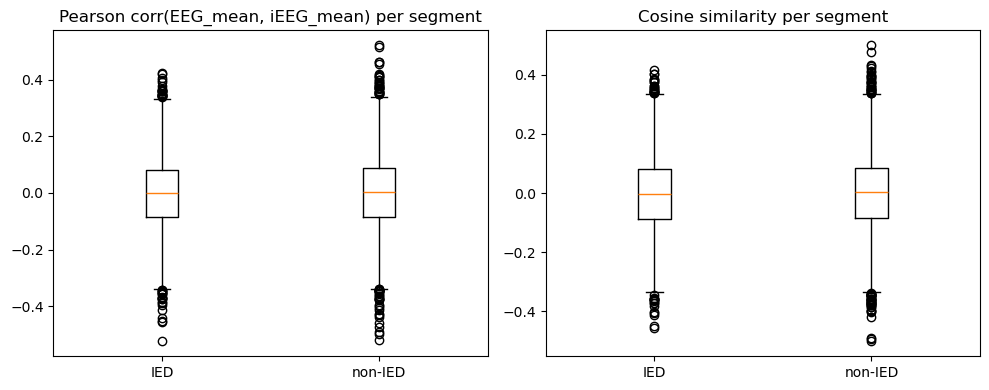


If IED pcorr/cossim isn't clearly higher than non-IED here (with no model involved),
the gap you're seeing in your mapping model is coming from segmentation / onset quality,
not the model itself. Try increasing PEAK_SEARCH_RADIUS_SAMPLES, double-check PEAK_CHANNELS,
or inspect whether the raw `onsets` array is even meant to mark IEDs visible on BOTH modalities.


In [12]:

# ---- 9.3 per-segment EEG<->iEEG pcorr / cosine similarity, IED vs non-IED ----
def seg_pcorr_cossim(seg_eeg, seg_ieeg):
    """seg_eeg: (seg_len, n_eeg_ch), seg_ieeg: (seg_len, n_ieeg_ch).
    Compares the channel-averaged EEG trace against the channel-averaged iEEG trace."""
    a = seg_eeg.mean(axis=1)    # (seg_len,)
    b = seg_ieeg.mean(axis=1)   # (seg_len,)
    if np.std(a) == 0 or np.std(b) == 0:
        pcorr = 0.0
    else:
        pcorr = float(np.corrcoef(a, b)[0, 1])
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    cossim = float(np.dot(a, b) / denom) if denom > 0 else 0.0
    return pcorr, cossim


pcorrs  = np.empty(len(y))
cossims = np.empty(len(y))
for k in range(len(y)):
    pcorrs[k], cossims[k] = seg_pcorr_cossim(X_eeg[k], X_ieeg[k])

print(f"Mean pcorr   IED: {pcorrs[y==1].mean():.4f}   non-IED: {pcorrs[y==0].mean():.4f}")
print(f"Mean cossim  IED: {cossims[y==1].mean():.4f}   non-IED: {cossims[y==0].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot([pcorrs[y == 1], pcorrs[y == 0]], labels=["IED", "non-IED"])
axes[0].set_title("Pearson corr(EEG_mean, iEEG_mean) per segment")
axes[1].boxplot([cossims[y == 1], cossims[y == 0]], labels=["IED", "non-IED"])
axes[1].set_title("Cosine similarity per segment")
plt.tight_layout()
plt.show()

print("\nIf IED pcorr/cossim isn't clearly higher than non-IED here (with no model involved),")
print("the gap you're seeing in your mapping model is coming from segmentation / onset quality,")
print("not the model itself. Try increasing PEAK_SEARCH_RADIUS_SAMPLES, double-check PEAK_CHANNELS,")
print("or inspect whether the raw `onsets` array is even meant to mark IEDs visible on BOTH modalities.")


## 10. Save Stage 2 `.npz` (paired eeg / iEEG, balanced, peak-aligned)

Kept as **two arrays** (`X_eeg`, `X_ieeg`) rather than one concatenated channel blob, so a
scEEG→iEEG model (VAE-CGAN, CNN-BiLSTM, etc.) can load `X_eeg` as input and `X_ieeg` as the
reconstruction/generation target directly — `X_eeg[k]` and `X_ieeg[k]` are guaranteed to be
the same time window, same subject, same label.

Shapes are saved `(N, seg_len, n_channels)` — "channels-last". For PyTorch `Conv1d`/`LSTM`
you'll typically want `(N, n_channels, seg_len)`; just `.transpose(0, 2, 1)` after loading.

In [13]:

np.savez(
    NPZ_OUT,
    X_eeg=X_eeg,                           # (N, 64, 20) float32
    X_ieeg=X_ieeg,                         # (N, 64, 12) float32
    y=y,                                   # (N,) int, 1=IED, 0=non-IED
    subject_ids=seg_subject_ids,           # (N,) which subject each segment came from
    eeg_names=np.array(eeg_names),
    fo_names=np.array(fo_names),
    fs=fs,
    seg_len=SEG_LEN,
    half_win=HALF_WIN,
    guard_mult=GUARD_MULT,
    refine_peak=REFINE_PEAK,
    peak_search_radius_samples=PEAK_SEARCH_RADIUS_SAMPLES,
    peak_channels=PEAK_CHANNELS,
)
print("Saved:", NPZ_OUT)
print("File size (MB):", os.path.getsize(NPZ_OUT) / 1e6)


Saved: .\balanced_segmented_dataset.npz
File size (MB): 105.073585


## 11. Save Stage 3 `.npz` — leftover (unused) non-IED segments

Real, valid, non-overlapping non-IED windows (far from every peak for their subject)
found while building the balanced set in Stage 2 but not needed to match that subject's
IED count.

In [14]:

np.savez(
    LEFTOVER_NPZ,
    X_eeg=X_eeg_leftover,                  # (N_leftover, 64, 20) float32 -- all label 0 (non-IED)
    X_ieeg=X_ieeg_leftover,                # (N_leftover, 64, 12) float32
    start_idx=leftover_starts_all,         # (N_leftover,) sample index each window starts at
    subject_ids=leftover_subject_ids,      # (N_leftover,) which subject each segment came from
    eeg_names=np.array(eeg_names),
    fo_names=np.array(fo_names),
    fs=fs,
    seg_len=SEG_LEN,
    half_win=HALF_WIN,
    guard_mult=GUARD_MULT,
)
print("Saved:", LEFTOVER_NPZ)
print("File size (MB):", os.path.getsize(LEFTOVER_NPZ) / 1e6)
print("Total leftover non-IED segments:", len(leftover_starts_all))


Saved: .\leftover_non_ied_segments.npz
File size (MB): 427.428908
Total leftover non-IED segments: 51973


## 12. Save `.csv` (wide format, self-contained) — balanced dataset only

One row per segment. Columns: `subject_id`, `segment_id`, `label`, then
`eeg_<channel>__t<k>` for every scalp channel × 64 samples, then `ieeg_<channel>__t<k>`
for every iEEG channel × 64 samples. This file is large — expect a few hundred MB.

In [15]:

n_segments = X_eeg.shape[0]

eeg_cols  = [f"eeg_{ch}__t{t}"  for ch in eeg_names for t in range(SEG_LEN)]
ieeg_cols = [f"ieeg_{ch}__t{t}" for ch in fo_names  for t in range(SEG_LEN)]

X_eeg_flat  = X_eeg.transpose(0, 2, 1).reshape(n_segments, -1)    # (N, n_eeg_ch*seg_len)
X_ieeg_flat = X_ieeg.transpose(0, 2, 1).reshape(n_segments, -1)   # (N, n_ieeg_ch*seg_len)

df = pd.DataFrame(np.concatenate([X_eeg_flat, X_ieeg_flat], axis=1),
                   columns=eeg_cols + ieeg_cols)
df.insert(0, "label", y)
df.insert(0, "segment_id", np.arange(n_segments))
df.insert(0, "subject_id", seg_subject_ids)

df.to_csv(CSV_OUT, index=False)
print("Saved:", CSV_OUT)
print("CSV shape:", df.shape)
print("File size (MB):", os.path.getsize(CSV_OUT) / 1e6)
df.head()


Saved: .\balanced_segmented_dataset.csv
CSV shape: (12776, 2051)
File size (MB): 370.11281


,subject_id,segment_id,label,eeg_Fp1__t0,eeg_Fp1__t1,eeg_Fp1__t2,eeg_Fp1__t3,eeg_Fp1__t4,eeg_Fp1__t5,eeg_Fp1__t6,...,ieeg_RFO6__t54,ieeg_RFO6__t55,ieeg_RFO6__t56,ieeg_RFO6__t57,ieeg_RFO6__t58,ieeg_RFO6__t59,ieeg_RFO6__t60,ieeg_RFO6__t61,ieeg_RFO6__t62,ieeg_RFO6__t63
0,sub-11,0,1,-0.000034,-0.000028,-0.000021,-0.000017,-0.000016,-0.000016,-0.000017,...,0.000033,0.000017,0.000037,0.000058,0.000047,0.000031,3.528779e-05,0.000049,0.000054,5.758344e-05
1,sub-03,1,1,-0.000002,-0.000001,0.000002,0.000005,0.000007,0.000006,0.000002,...,0.000099,0.000061,0.000020,0.000013,0.000030,0.000026,3.939324e-07,0.000031,0.000090,9.194611e-05
2,sub-18,2,0,-0.000005,0.000002,-0.000001,-0.000010,-0.000018,-0.000020,-0.000018,...,-0.000123,-0.000146,-0.000142,-0.000151,-0.000151,-0.000088,-4.413211e-05,-0.000071,-0.000063,7.318402e-07
3,sub-16,3,1,0.000008,-0.000008,-0.000023,-0.000036,-0.000044,-0.000050,-0.000052,...,-0.003536,-0.003490,-0.003447,-0.003445,-0.003398,-0.003386,-3.501488e-03,-0.003290,-0.003171,-3.641440e-03
4,sub-02,4,0,0.000013,0.000014,0.000013,0.000013,0.000017,0.000023,0.000027,...,-0.000073,-0.000066,-0.000047,-0.000035,-0.000028,-0.000011,3.018657e-06,-0.000005,-0.000017,-3.833152e-05


## 13. Subject-wise train / val / test split (balanced dataset, ready to train on)

Splits **whole subjects** into train/val/test (not individual segments), so no subject's
data leaks across splits.

In [16]:

unique_subjects = list(subject_ids)
rng.shuffle(unique_subjects)

n_train = max(1, round(len(unique_subjects) * TRAIN_FRAC))
n_val   = max(1, round(len(unique_subjects) * VAL_FRAC))
train_subjects = unique_subjects[:n_train]
val_subjects   = unique_subjects[n_train:n_train + n_val]
test_subjects  = unique_subjects[n_train + n_val:]

print("Train subjects:", train_subjects)
print("Val subjects  :", val_subjects)
print("Test subjects :", test_subjects)

def subset(mask_subjects):
    m = np.isin(seg_subject_ids, mask_subjects)
    return X_eeg[m], X_ieeg[m], y[m], seg_subject_ids[m]

Xe_tr, Xi_tr, y_tr, s_tr = subset(train_subjects)
Xe_va, Xi_va, y_va, s_va = subset(val_subjects)
Xe_te, Xi_te, y_te, s_te = subset(test_subjects)

print(f"\nTrain: {len(y_tr)} segments  Val: {len(y_va)} segments  Test: {len(y_te)} segments")

np.savez(
    SPLIT_OUT,
    X_eeg_train=Xe_tr, X_ieeg_train=Xi_tr, y_train=y_tr, subject_ids_train=s_tr,
    X_eeg_val=Xe_va,   X_ieeg_val=Xi_va,   y_val=y_va,   subject_ids_val=s_va,
    X_eeg_test=Xe_te,  X_ieeg_test=Xi_te,  y_test=y_te,  subject_ids_test=s_te,
    eeg_names=np.array(eeg_names), fo_names=np.array(fo_names),
    fs=fs, seg_len=SEG_LEN, half_win=HALF_WIN,
)
print("\nSaved:", SPLIT_OUT)


Train subjects: [np.str_('sub-01'), np.str_('sub-05'), np.str_('sub-15'), np.str_('sub-17'), np.str_('sub-08'), np.str_('sub-04'), np.str_('sub-07'), np.str_('sub-14'), np.str_('sub-16'), np.str_('sub-11'), np.str_('sub-12'), np.str_('sub-18'), np.str_('sub-09')]
Val subjects  : [np.str_('sub-13'), np.str_('sub-03'), np.str_('sub-02')]
Test subjects : [np.str_('sub-10'), np.str_('sub-06')]

Train: 9180 segments  Val: 2408 segments  Test: 1188 segments

Saved: .\balanced_segmented_dataset_split.npz


## Done — three output files

| stage | file | labeled? | balanced? | contents |
|---|---|---|---|---|
| 1 | `segmented_dataset.npz` | No | No | every 64-sample (250 ms) chunk of every subject's *entire* recording |
| 2 | `balanced_segmented_dataset.npz` (+ `.csv`, `_split.npz`) | Yes (`y`) | Yes, per subject | `n_target` peak-aligned IED + `n_target` non-IED per subject |
| 3 | `leftover_non_ied_segments.npz` | No (all non-IED) | N/A | valid non-overlapping non-IED windows found per subject but not used to balance Stage 2 |

**What changed vs. the previous notebook:** Stage 2's IED windows are now centered on a
**refined true peak** (Section 5) instead of the raw `onsets` marker, and Section 9 gives
you three concrete ways to check the fix worked *before* you re-run your mapping model:
the single-example plot, the grand-average `|amplitude|` bump at index 32, and — most
directly relevant to your question — the per-segment pcorr/cossim box-plots comparing
IED vs non-IED with no model involved at all.

If, after this fix, IED pcorr/cossim in Section 9.3 is still barely above non-IED, that's
strong evidence the problem isn't your segmentation code but something about the `onsets`
array itself (e.g. it may include some borderline/artifact detections, or IEDs that are
only weakly expressed in the scalp EEG — which, for many patients, is expected and is
part of why the scEEG→iEEG mapping task is hard in the first place).

- **Reshaping for PyTorch (Conv1d / LSTM expect channels before time):**
  ```python
  X_eeg_ct  = X_eeg.transpose(0, 2, 1)   # (N, 20, 64)
  X_ieeg_ct = X_ieeg.transpose(0, 2, 1)  # (N, 12, 64)
  ```
- **Normalization:** z-score or min-max normalize per channel using **train-split
  statistics only** (fit on `Xe_tr`/`Xi_tr` from Section 13, apply to val/test) to avoid
  leakage.
